    
### DFL 전체 파이프라인 (Forward Pass)

    Args:
        z          : (batch, input_dim)  - 입력 피처
        r_real     : (batch, N, m)       - 실현 수익률 (ground truth)
        pred_model : PredictionModel
        opt_layer  : CvxpyLayer
        n1         : drawdown 한도 비율
        C          : 자본 규모
        d          : 연수
        x_min      : 최소 비중
        x_max      : 최대 비중
        lam        : MDD 패널티 가중치
    
    Returns:
        dict with keys:
            r_hat   : (batch, N, m)  예측 수익률
            y_hat   : (batch, N, m)  예측 누적 수익률
            x_star  : (batch, m)     최적 포트폴리오
            y_real  : (batch, N, m)  실현 누적 수익률
            w_real  : (batch, N)     실현 포트폴리오 경로
            R_real  : (batch,)       실현 수익률
            M_real  : (batch,)       실현 MDD
            loss    : scalar         DFL Loss

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import torch
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import yfinance as yf
import random
from dataclasses import dataclass
from typing import Dict, Tuple
from tqdm import tqdm
import itertools
import torch.nn as nn
import torch.optim as optim


    
    
### MDD Formulation을 cvxpylayers로 구성

    목적함수:
        max  (1/dC) * y_hat(N)^T x
        (dC는 상수이므로 y_hat(N)^T x 최대화와 동치)

    제약식:
        u_k - y_hat_k^T x <= n1 * C,    k = 1,...,N   (drawdown 상한)
        u_k >= y_hat_k^T x,              k = 1,...,N   (running max >= 현재값)
        u_k >= u_{k-1},                  k = 1,...,N   (running max 단조증가)
        u_0 = 0
        x_min <= x_i <= x_max,          i = 1,...,m   (box constraint)

    Parameters (cvxpy):
        Y_hat : (N, m) - 예측 누적 수익률 경로 (각 행이 y_hat(t))
        n1C   : scalar - 허용 최대 drawdown 한도 (n1 * C)
        x_min : scalar
        x_max : scalar

    Returns:
        CvxpyLayer - differentiable optimization layer
    

In [48]:
inds_10 = pd.read_csv('csv/10_industry.csv')
inds_10['Date'] = pd.to_datetime(inds_10['Date'])
inds_10 = inds_10.set_index('Date')
inds_10.info()
inds_10

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6539 entries, 2000-01-03 to 2025-12-31
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NoDur   6539 non-null   float64
 1   Durbl   6539 non-null   float64
 2   Manuf   6539 non-null   float64
 3   Enrgy   6539 non-null   float64
 4   HiTec   6539 non-null   float64
 5   Telcm   6539 non-null   float64
 6   Shops   6539 non-null   float64
 7   Hlth    6539 non-null   float64
 8   Utils   6539 non-null   float64
 9   Other   6539 non-null   float64
dtypes: float64(10)
memory usage: 561.9 KB


,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
Date,,,,,,,,,,
2000-01-03,-1.65,-1.36,-2.49,-3.08,2.47,-1.26,-2.30,-0.58,-2.37,-3.31
2000-01-04,-1.81,-2.60,-2.68,-1.96,-5.34,-4.40,-3.28,-4.39,0.47,-3.68
2000-01-05,-0.13,-0.04,0.57,2.26,-1.09,0.01,-0.38,2.32,3.48,-0.38
2000-01-06,0.68,0.58,2.17,4.00,-4.93,-1.92,0.24,2.68,0.57,2.34
2000-01-07,2.11,4.81,3.21,1.16,3.51,0.93,4.27,7.61,1.13,1.99
...,...,...,...,...,...,...,...,...,...,...
2025-12-24,0.36,0.00,0.46,-0.33,0.17,0.64,0.51,0.58,0.38,0.42
2025-12-26,-0.07,-1.65,-0.13,-0.30,0.09,-0.18,0.13,-0.05,-0.16,-0.05
2025-12-29,0.19,-2.68,-0.38,1.02,-0.40,0.43,-0.21,-0.26,0.26,-0.57


In [52]:
torch.manual_seed(42)

N_STOCKS   = len(inds_10.columns)
LOOKBACK   = 21
HORIZON    = 21

INPUT_DIM  = LOOKBACK * N_STOCKS
HIDDEN_DIM = 128
N          = HORIZON
M          = N_STOCKS

n1    = 0.30
C     = 1.0
d     = 1.0
x_min = 0.0
x_max = 0.30
lam   = 1.0

EPOCHS     = 100
BATCH_SIZE = 16
LR         = 1e-3

In [53]:
inds_10 = inds_10.sort_index()   # ← 이 한 줄 추가
inds_10 = inds_10[~inds_10.index.duplicated(keep='first')]  # ← 없음
inds_10 = inds_10 / 100.0

stock_names = inds_10.columns.tolist()

# =============================================================================
# 2. IS / OOS 분리 (날짜 기준)
# =============================================================================
IS_START = "2000-01-01"
IS_END   = "2019-12-31"
BT_START = "2020-01-01"
BT_END   = "2025-12-31"

is_df = inds_10[IS_START : IS_END]
bt_df = inds_10[BT_START : BT_END]

is_np  = is_df.values
bt_np  = bt_df.values

N_IS   = len(is_df)
N_BT   = len(bt_df)
N_DAYS = len(inds_10)

print(f"전체 : {inds_10.index[0].date()} → {inds_10.index[-1].date()}  ({N_DAYS} days)")
print(f"IS   : {is_df.index[0].date()} → {is_df.index[-1].date()}  ({N_IS} days)")
print(f"BT   : {bt_df.index[0].date()} → {bt_df.index[-1].date()}  ({N_BT} days)")
print(f"종목 : {stock_names}")

# =============================================================================
# 3. 슬라이딩 윈도우 생성
# =============================================================================
def make_windows(r_np, lookback, horizon, start, end):
    samples = []
    for t in range(start, end - horizon + 1):
        z      = r_np[t - lookback : t].flatten()
        r_real = r_np[t : t + horizon]
        samples.append((z, r_real))
    return samples

is_samples = make_windows(is_np, LOOKBACK, HORIZON,
                          start=LOOKBACK, end=N_IS)

full_np      = np.vstack([is_np, bt_np])
BT_START_IDX = N_IS

rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                             start=BT_START_IDX, end=BT_START_IDX + N_BT)
rebal_samples = rebal_samples[::HORIZON]

is_years = (is_df.index[-1] - is_df.index[0]).days / 365.25
bt_years = (bt_df.index[-1] - bt_df.index[0]).days / 365.25

print(f"\nIS 학습 샘플 수  : {len(is_samples)}")
print(f"BT 리밸런싱 횟수 : {len(rebal_samples)}")
print(f"IS : ... ({N_IS} rows / {is_years:.1f}년)")
print(f"BT : ... ({N_BT} rows / {bt_years:.1f}년)")



전체 : 2000-01-03 → 2025-12-31  (6539 days)
IS   : 2000-01-03 → 2019-12-31  (5031 days)
BT   : 2020-01-02 → 2025-12-31  (1508 days)
종목 : ['NoDur', 'Durbl', 'Manuf', 'Enrgy', 'HiTec', 'Telcm', 'Shops', 'Hlth', 'Utils', 'Other']

IS 학습 샘플 수  : 4990
BT 리밸런싱 횟수 : 71
IS : ... (5031 rows / 20.0년)
BT : ... (1508 rows / 6.0년)



── IS Training ──
  Epoch   1/100  loss = 0.000372
  Epoch   5/100  loss = 0.000372
  Epoch  10/100  loss = 0.000372
  Epoch  15/100  loss = 0.000372
  Epoch  20/100  loss = 0.000372
  Epoch  25/100  loss = 0.000372
  Epoch  30/100  loss = 0.000372
  Epoch  35/100  loss = 0.000372
  Epoch  40/100  loss = 0.000372
  Epoch  45/100  loss = 0.000372
  Epoch  50/100  loss = 0.000372
  Epoch  55/100  loss = 0.000372
  Epoch  60/100  loss = 0.000372
  Epoch  65/100  loss = 0.000372
  Epoch  70/100  loss = 0.000372
  Epoch  75/100  loss = 0.000372
  Epoch  80/100  loss = 0.000372
  Epoch  85/100  loss = 0.000372
  Epoch  90/100  loss = 0.000372
  Epoch  95/100  loss = 0.000372
  Epoch 100/100  loss = 0.000372

── Backtest : DFL-MDD ──
 Win    R_real    MDD(%)  Top-3 weights
-----------------------------------------------------------------


Backtesting: 100%|██████████| 71/71 [00:00<00:00, 896.07it/s]

    1    0.0003   0.0222%  {'Other': 0.3, 'Utils': 0.3, 'Durbl': 0.3}
    2   -0.0006   0.1535%  {'Other': 0.3, 'Utils': 0.3, 'Durbl': 0.3}
    3   -0.0023   0.3973%  {'Other': 0.3, 'Utils': 0.3, 'Durbl': 0.3}
    4    0.0016   0.0618%  {'Other': 0.3, 'Utils': 0.3, 'Durbl': 0.3}
    5    0.0012   0.0524%  {'Other': 0.3, 'Utils': 0.3, 'Durbl': 0.3}
    6    0.0002   0.1029%  {'Other': 0.3, 'Utils': 0.3, 'Durbl': 0.3}
    7    0.0008   0.0259%  {'Other': 0.3, 'Utils': 0.3, 'Durbl': 0.3}
    8    0.0013   0.0096%  {'Other': 0.3, 'Utils': 0.3, 'Durbl': 0.3}
    9   -0.0004   0.0862%  {'Other': 0.3, 'Utils': 0.3, 'Durbl': 0.3}
   10    0.0002   0.0562%  {'Other': 0.3, 'Utils': 0.3, 'Durbl': 0.3}
   11    0.0014   0.0157%  {'Other': 0.3, 'Utils': 0.3, 'Durbl': 0.3}
   12    0.0006   0.0199%  {'Other': 0.3, 'Utils': 0.3, 'Durbl': 0.3}
   13    0.0006   0.0506%  {'Other': 0.3, 'Utils': 0.3, 'Durbl': 0.3}
   14   -0.0002   0.0683%  {'Other': 0.3, 'Utils': 0.3, 'Durbl': 0.3}
   15    0.0005   0.

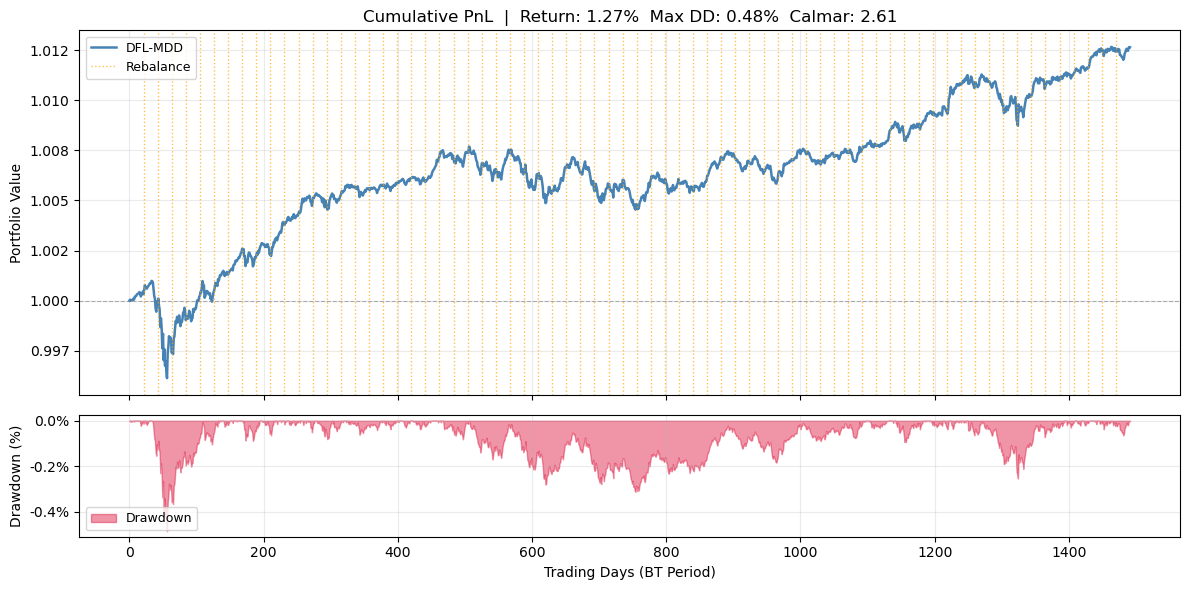


── PnL Summary (DFL-MDD) ──
  Final Value  : 1.0127
  Total Return : 1.2651%
  Max Drawdown : 0.4850%
  Calmar Ratio : 2.6085


In [54]:

from dfl_mdd import (
    PredictionModel,
    build_optimization_layer,
    solve_portfolio,
    compute_cumulative_path,
    compute_realized_path,
    compute_return,
    compute_max_drawdown,
    dfl_loss,
    forward_pass,
    backtest_dfl_mdd,
    plot_pnl,
)

pred_model = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
opt_layer  = build_optimization_layer(N, M)
optimizer  = optim.Adam(pred_model.parameters(), lr=LR)


zs_is = torch.tensor(np.array([s[0] for s in is_samples]), dtype=torch.float32)
rs_is = torch.tensor(np.array([s[1] for s in is_samples]), dtype=torch.float32)

print("\n── IS Training ──")
pred_model.train()

for epoch in range(EPOCHS):
    perm   = torch.randperm(len(is_samples))
    ep_loss = []

    for i in range(0, len(is_samples), BATCH_SIZE):
        idx = perm[i : i + BATCH_SIZE]
        z_b = zs_is[idx]
        r_b = rs_is[idx]

        optimizer.zero_grad()
        result = forward_pass(z_b, r_b, pred_model, opt_layer,
                              n1, C, d, x_min, x_max, lam)
        result["loss"].backward()
        optimizer.step()
        ep_loss.append(result["loss"].item())

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS}  loss = {np.mean(ep_loss):.6f}")


bt_dfl_mdd = backtest_dfl_mdd(
    pred_model    = pred_model,
    opt_layer     = opt_layer,
    rebal_samples = rebal_samples,
    N             = HORIZON,
    d             = d,
    C             = C,
    n1            = n1,
    x_min         = x_min,
    x_max         = x_max,
    stock_names   = stock_names,
)


plot_pnl(bt_dfl_mdd, horizon=HORIZON, label = "DFL-MDD")

In [ ]:
# from pto_mdd  import train_pto_mdd,  backtest_pto_mdd
# from pto_mvo  import train_pto_mvo,  backtest_pto_mvo 

# # 각 모델은 독립적인 PredictionModel 인스턴스 사용 (가중치 공유 X)
# model_pto_mdd = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
# model_pto_mvo = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)

# train_pto_mdd(model_pto_mdd, is_samples, EPOCHS, BATCH_SIZE, LR)
# train_pto_mvo(model_pto_mvo, is_samples, EPOCHS, BATCH_SIZE, LR)


# bt_pto_mdd = backtest_pto_mdd(
#     pred_model   = model_pto_mdd,
#     rebal_samples= rebal_samples,
#     N            = HORIZON,
#     d            = d,
#     C            = C,
#     n1           = n1,
#     x_min        = x_min,
#     x_max        = x_max,
#     stock_names  = stock_names,
# )

# bt_pto_mvo = backtest_pto_mvo(
#     pred_model   = model_pto_mvo,
#     rebal_samples= rebal_samples,
#     N            = HORIZON,
#     d            = d,
#     C            = C,
#     lam_mvo      = 1.0,
#     x_min        = x_min,
#     x_max        = x_max,
#     stock_names  = stock_names,
# )

# plot_pnl(bt_pto_mdd, horizon=HORIZON, label = 'PTO-MDD')
# plot_pnl(bt_pto_mvo, horizon=HORIZON, label = 'PTO-MVO')